In [1]:
!ls
!ls SpamBase/

Assign4.ipynb  data  Experiment_4.pdf
ls: cannot access 'SpamBase/': No such file or directory


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

# Loading and basic data exploration

In [3]:
def load_dataset(filepath,column_names=None,seperator=","):
    df=pd.read_csv(filepath,names=column_names,sep=seperator)
    df.columns = df.columns.str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-"*50)

    print("\n Shape: ",df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())

    print("\nData Types: ")
    print(df.dtypes)

    print("\nMemory information")
    df.info()

    print("First 5 elements")
    print(df.head())
def missing_values(df):
    missing=df.isnull().sum()
    percent=(missing/len(df) )*100

    result=pd.DataFrame(
    {"missing":missing,
    "percent":percent
    })

    print(result)

    if (missing.sum() ==0):
        print("There is no missing value!")
    else:
        print("\033[31mMissing Values detected\033[0m")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ",duplicates);

    if(duplicates ==0):
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")

    return duplicates

def summary_statistics(df):
    print("\nSummary statsitics")
    print(df.describe())

   

In [4]:
def basic_eda(filepath,column_names=None,separator=",",):

    
    df = load_dataset(
        filepath,
        column_names=column_names,
        seperator=separator
    )

    print("\nLoading dataset completed\n")

    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)

    return df
def class_distribution(df,target_column):
    print("\nClass Distribution")

    counts=df[target_column].value_counts()
    plot=counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")

    for container in plot.containers:
        plot.bar_label(container)
    plt.show()


In [5]:
df=basic_eda("data//spambase_csv.csv")
print(df)


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (4601, 58)

Columns: 
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_p


Class Distribution


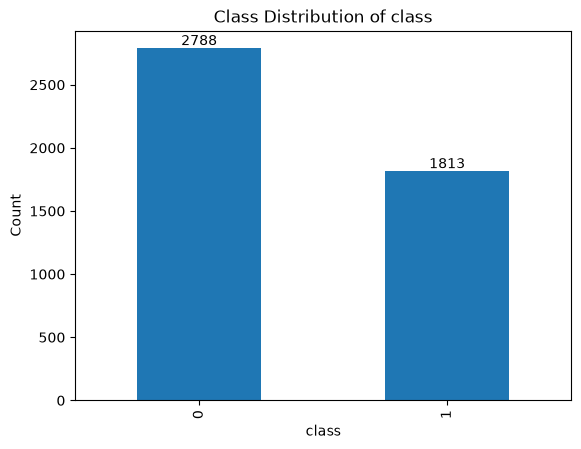

In [6]:
class_distribution(df,"class")

# Preprocessing The Data - using simpleimputer to handle missing data 
# Standardized Using Standard Scaler
# Split into train,test by train

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def preprocess_data(df,target_col,test_size=0.2,random_state=42,impute_strategy="median"):
    X = df.drop(columns=[target_col])
    Y = df[target_col]

    x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=test_size,
    random_state=42,stratify=Y)

    imputer=SimpleImputer(strategy=impute_strategy)

    x_train = imputer.fit_transform(x_train)
    x_test = imputer.transform(x_test)

    scaler = StandardScaler()

    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    return x_train,x_test,y_train,y_test

In [8]:
x_train,x_test,y_train,y_test = preprocess_data(df,target_col="class")

# Baseline Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression
import time

start=time.time()
lr_model = LogisticRegression(random_state=42)
lr_model.fit(x_train,y_train) 
lr_train_time = time.time()-start

start = time.time()
y_pred = lr_model.predict(x_test)
y_prob = lr_model.predict_proba(x_test)[:,1]
lr_predict_time = time.time() - start

In [10]:
def classification_metrics(y_test,y_pred,y_prob):
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test , y_pred)
    roc_auc = roc_auc_score ( y_test,y_prob)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

In [11]:
print(f"Logistic Regression")
classification_metrics(y_test,y_pred,y_prob)
print(f"Training Time : {lr_train_time:.4f} sec")
print(f"Prediction Time: {lr_predict_time:.4f} sec")

Logistic Regression
Accuracy : 0.9294
Precision: 0.9209
Recall   : 0.8981
F1 Score : 0.9093
ROC AUC  : 0.9702
Training Time : 0.0207 sec
Prediction Time: 0.0006 sec


# Hyperparameter Tuning Using RandomizedSearchCV


In [12]:
LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [13]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

param_dist = { "penalty":["l1","l2"],
               "C" : [0.01,0.1,1,10,100],
               "solver": ["liblinear","saga"]
             }

random_search = RandomizedSearchCV(
    estimator = LogisticRegression(random_state=42,max_iter=1000),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,scoring ="accuracy",
    random_state=42,
    n_jobs=-1
)

start = time.time()
random_search.fit(x_train,y_train)
random_search_time =time.time() - start


In [14]:
print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Accuracy:", random_search.best_score_)
best_lr = random_search.best_estimator_

Best Parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 100}
Best Cross Validation Accuracy: 0.923913043478261


In [15]:
start= time.time()
y_pred = best_lr.predict(x_test)
y_prob = best_lr.predict_proba(x_test)[:,1]
predict_time= time.time() -start

print("After Hypertuning Logistic Regression")
classification_metrics(y_test,y_pred,y_prob)

print(f"Random search Train Time: {random_search_time:.4f} sec")
print(f"Prediction Time: {predict_time:.4f} sec")

After Hypertuning Logistic Regression
Accuracy : 0.9294
Precision: 0.9209
Recall   : 0.8981
F1 Score : 0.9093
ROC AUC  : 0.9706
Random search Train Time: 7.8687 sec
Prediction Time: 0.0010 sec


# Training SVM in different kernels

In [19]:
from sklearn.svm import SVC

kernels = ["linear","poly","rbf","sigmoid"]
svm_results=[]

for kernel in kernels:
    start = time.time()
    svm_linear = SVC (kernel=kernel,
                      degree=3,
                      random_state=42
                     )
    svm_linear.fit(x_train,y_train)
    train_time = time.time() - start

    y_pred = svm_linear.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    svm_results.append({'Kernel' : kernel.capitalize(),
    'Accuracy':round(acc,4),
    'F! Score' : round(f1,4),
    'Training Time (s)' : round(train_time,4)
                       })
svm_kernel_df = pd.DataFrame(svm_results)
print("--- SVM kernel-wise Performance ---")
print(svm_kernel_df)

--- SVM kernel-wise Performance ---
    Kernel  Accuracy  F! Score  Training Time (s)
0   Linear    0.9294    0.9093             0.2364
1     Poly    0.7796    0.6220             0.1943
2      Rbf    0.9273    0.9055             0.1077
3  Sigmoid    0.8849    0.8528             0.1359


# SVM Hyperparameter Tuning using GridSearchCV

In [21]:
from sklearn.model_selection import GridSearchCV
param_grid_svm={'C':[0.1,1,10,100],
                'gamma':['scale','auto'],
                'kernel':['rbf','linear','poly'],
                'degree':[2,3,4]
               }
grid_svm = GridSearchCV(
    estimator = SVC(random_state=42,probability=True),
    param_grid = param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

start = time.time()
grid_svm.fit(x_train,y_train)
svm_tune_time = time.time() - start

print("Best Parameters:", grid_svm.best_params_)
print("Best Cross Validation Accuracy:", round(grid_svm.best_score_, 4))
print(f"Grid Search Time: {svm_tune_time:.4f} sec")

best_svm = grid_svm.best_estimator_

Best Parameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross Validation Accuracy: 0.9332
Grid Search Time: 275.3843 sec


# Evaluating models

In [22]:
start = time.time()
y_pred_svm = best_svm.predict(x_test)
y_prob_svm = best_svm.predict_proba(x_test)[:, 1]
svm_predict_time = time.time() - start

print("--- Tuned SVM Performance ---")
classification_metrics(y_test, y_pred_svm, y_prob_svm)

print(f"Prediction Time: {svm_predict_time:.4f} sec")

--- Tuned SVM Performance ---
Accuracy : 0.9207
Precision: 0.9143
Recall   : 0.8815
F1 Score : 0.8976
ROC AUC  : 0.9702
Prediction Time: 0.0905 sec


# 5 Fold Cross validation Comparison Table

In [23]:
from sklearn.model_selection import cross_val_score
lr_cv_scores = cross_val_score(best_lr, x_train, y_train, cv=5, scoring='accuracy')
svm_cv_scores = cross_val_score(best_svm, x_train, y_train, cv=5, scoring='accuracy')

cv_data = {
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Logistic Regression': [round(score, 4) for score in lr_cv_scores],
    'SVM': [round(score, 4) for score in svm_cv_scores]
}

cv_df = pd.DataFrame(cv_data)
cv_df.loc[len(cv_df)] = [
    'Average',
    round(lr_cv_scores.mean(), 4),
    round(svm_cv_scores.mean(), 4)
]

print("--- K-Fold Cross-Validation Results (K=5) ---")
print(cv_df)


--- K-Fold Cross-Validation Results (K=5) ---
      Fold  Logistic Regression     SVM
0   Fold 1               0.9402  0.9429
1   Fold 2               0.9158  0.9321
2   Fold 3               0.9226  0.9334
3   Fold 4               0.9171  0.9212
4   Fold 5               0.9239  0.9361
5  Average               0.9239  0.9332
